## **1. Introdução e Contexto**

Este *notebook* tem como objetivo realizar uma *Exploratory Data Analysis* (EDA), essencial para a compreensão inicial do *dataset*. O foco principal é um problema de Classificação, onde pretendemos prever a aptidão física de um indivíduo.

- **Repositório:** https://www.kaggle.com/datasets/kukuroo3/body-performance-data
- **Finalidade:** Preparar os dados, identificar padrões, avaliar a qualidade das features e entender a distribuição da variável-alvo.


## **2. Justificação e Estrutura do Dataset**

O *dataset* em questão é uma coleção de medições de aptidão física e características demográficas, com o objetivo de classificar um indivíduo numa das classes de desempenho.

- **Variável-Alvo (*class*):** A coluna *class* (A, B, C, D) é a variável que pretendemos prever.

- **Variáveis Preditivas (*Features*):** Incluem características demográficas (*age, gender*), medidas corporais (*height_cm, weight_kg, body fat_%*), métricas de saúde (*diastolic, systolic*) e resultados de testes físicos (*gripForce, sit and bend forward_cm, sit-ups counts, broad jump_cm*).

- **Contexto da Classificação:** Para modelos de classificação, o EDA deve concentrar-se em:

  - **Distribuição da Classe:** O *dataset* está equilibrado?

  - **Diferenças entre Classes:** As *features* numéricas têm distribuições diferentes para cada classe?

  - **Relação Feature-Classe:** Que *features* parecem ser as mais discriminatórias?

#### **Objetivos da EDA**

- Avaliar a Qualidade e Estrutura dos dados (tipos, valores em falta).

- Analisar o Desequilíbrio da variável-alvo (*class*).

- Identificar as *features* mais discriminatórias (que melhor separam as classes).

## **3. Carregamento, Estrutura e Estatísticas Descritivas**


Este capitulo carrega o *dataset* e realiza a primeira inspeção para verificar dimensões, tipos de dados e a presença de valores em falta.

In [65]:
# Importa as bibliotecas essenciais para manipulação, visualização e cálculo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o dataset
dataset_path = "data/bodyPerformance.csv" # Define o caminho do ficheiro de dados
df = pd.read_csv(dataset_path) # Carrega o ficheiro CSV para um DataFrame do Pandas, chamado 'df'

print("Dimensões do Dataset:", df.shape) # Imprime as dimensões do DataFrame: (número de linhas, número de colunas)
print("\nTipos de Dados:") 
print(df.dtypes)
print("\nValores em falta:")
print(df.isna().sum())
print("\nEstatísticas Descritivas:")
print(df.describe())

Dimensões do Dataset: (13393, 12)

Tipos de Dados:
age                        float64
gender                      object
height_cm                  float64
weight_kg                  float64
body fat_%                 float64
diastolic                  float64
systolic                   float64
gripForce                  float64
sit and bend forward_cm    float64
sit-ups counts             float64
broad jump_cm              float64
class                       object
dtype: object

Valores em falta:
age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

Estatísticas Descritivas:
                age     height_cm     weight_kg    body fat_%     diastolic  \
count  13393.000000  13393.00

#### **Interpretação dos Resultados (Carregamento)**

- **Dimensões:** O *dataset* possui 13393 linhas e 12 colunas.

- **Qualidade:** A contagem de valores em falta (df.isna().sum()) indica que o *dataset* é limpo, pois não existem *missing values* em nenhuma das colunas.

- **Estatísticas Descritivas:** O df.describe() fornece um resumo das *features* numéricas.

## **4. Análise da Variável-Alvo (class)**

Antes de construir qualquer modelo, é crucial entender a distribuição da variável que se pretende prever.

Contagem de Classes:
class
C    3349
D    3349
A    3348
B    3347
Name: count, dtype: int64


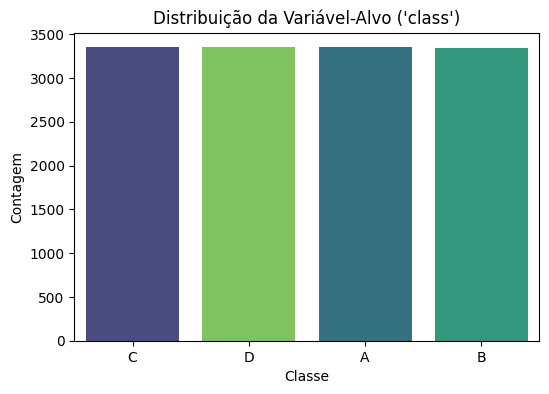

In [66]:
class_counts = df['class'].value_counts() # Conta o número de ocorrências de cada valor único na coluna 'class'

print("Contagem de Classes:")
print(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, order=class_counts.index, hue='class', palette='viridis', legend=False) # Cria um gráfico de barras para a contagem da variável 'class'
plt.title("Distribuição da Variável-Alvo ('class')")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show() 

#### **Interpretação da Distribuição da Variável-Alvo**

Este gráfico de contagem visualiza a frequência de cada classe de desempenho (A, B, C, D) no *dataset*.

O gráfico demonstra que o *dataset* está quase perfeitamente equilibrado:

- Todas as quatro classes (A, B, C, D) apresentam contagens extremamente próximas, rondando as 3348 instâncias por classe.

- A variação máxima entre a classe mais numerosa (C e D, 3349) e a menos numerosa (B, 3347) é de apenas 2 registos.

- A vantagem deste equilibrio é que elimina-se a necessidade de aplicar técnicas complexas de balanceamento de dados na fase de treino.

## **5. Análise Bivariada: Poder Discriminatório das Features**

Nesta secção, exploramos como as *features* numéricas se distribuem em função das classes. Os *Boxplots* são a ferramenta ideal para avaliar o poder discriminatório de um preditor.

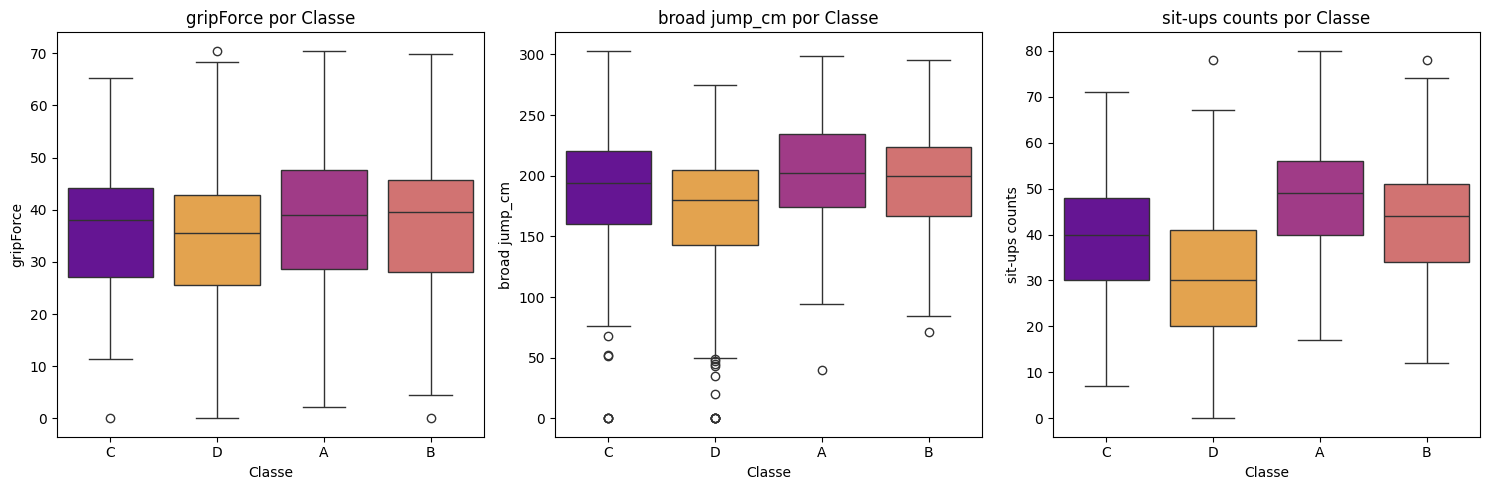

In [67]:
key_features = ['gripForce', 'broad jump_cm', 'sit-ups counts'] # Lista de features de desempenho físico a serem analisadas

plt.figure(figsize=(15, 5))
for i, feature in enumerate(key_features):
    plt.subplot(1, 3, i + 1)

    sns.boxplot(x='class', y=feature, data=df, order=class_counts.index, palette='plasma', hue='class', legend=False)
    plt.title(f'{feature} por Classe')
    plt.xlabel('Classe')
    plt.ylabel(feature)

plt.tight_layout()
plt.show() 

#### **Interpretação da Análise Bivariada (Boxplots)**

Estes três *boxplots* são essenciais na Análise Exploratória de Dados para a Classificação, pois avaliam o poder discriminatório das *features* numéricas mais relevantes. O objetivo é ver se as distribuições de cada *feature* variam significativamente em função da variável-alvo (*class*).

**1. Poder Discriminatório das Features**

- Em todos os gráficos, há uma separação clara nas distribuições (quartis e medianas) entre a Classe A e a Classe D é evidente.

**2. Comportamento das Classes e Relação Ordinal**

- **Classes A e B:** Tendem a agrupar-se nos valores mais altos para todas as *features* de desempenho físico, indicando que estas classes representam os grupos de maior aptidão.

- **Classes C e D:** Tendem a agrupar-se nos valores mais baixos, refletindo menor aptidão.

- A relação esperada (A > B > C > D) é mantida.

**3. Observação de Outliers**

- Todos os gráficos mostram pontos fora das caixas, que são potenciais *outliers*. Por exemplo, no gráfico *sit-ups counts*, a Classe C possui indivíduos com contagens muito baixas. No entanto, dado o forte poder discriminatório da distribuição principal, estes *outliers* não prejudicam a utilização destas *features*.

## **6. Relação da Variável Categórica (gender) com a Classe**

Analisamos o impacto da variável gender na distribuição da classe de desempenho.

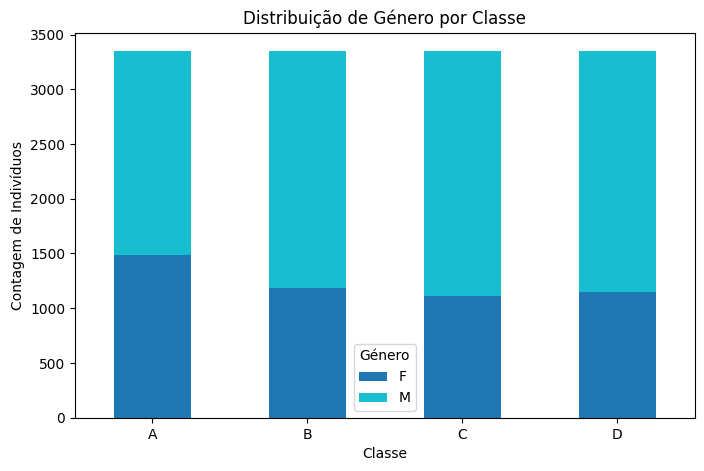

In [68]:
# Cria uma tabela dinâmica (pivot) para contar a ocorrência de cada género em cada classe
gender_class_pivot = df.groupby(['class', 'gender']).size().unstack(fill_value=0)
gender_class_pivot.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab10')
plt.title("Distribuição de Género por Classe")
plt.xlabel("Classe")
plt.ylabel("Contagem de Indivíduos")
plt.xticks(rotation=0)
plt.legend(title='Género')
plt.show() 

#### **Interpretação da Distribuição de Género por Classe**

Este gráfico de barras empilhadas é fundamental para a Análise Exploratória de Dados, pois revela a composição de género dentro de cada classe de aptidão física. A análise mostra se a variável *gender* é um fator forte na determinação da *class*, o que é crucial para a modelagem.

O gráfico demonstra uma clara e consistente distribuição de género em todas as classes, mas o balanço Homem/Mulher é praticamente uniforme em todo o *dataset*, com uma ligeira predominância masculina na classe A.

- Em todas as classes, a altura total da barra é praticamente idêntica, confirmando que o *dataset* está equilibrado em contagem total de instâncias por classe.

- Em todas as classes, a proporção de indivíduos masculinos e femininos é extremamente próxima de 50/50.



### **6.1 - Feature Engineering**

No âmbito do feature engineering, foi calculado o Índice de Massa Corporal (IMC) a partir das variáveis peso e altura, de acordo com a fórmula IMC = peso / altura². A inclusão desta variável teve como objetivo condensar informação relevante das features originais numa única métrica fisiológica, permitindo avaliar o seu impacto no poder discriminatório do conjunto de dados e no desempenho dos modelos de classificação.

In [69]:
df["IMC"] = df["weight_kg"] / ((df["height_cm"] / 100) ** 2)
df["IMC"] = df["IMC"].round(2)

## **7. Matriz de Correlação das Variáveis Numéricas**

A matriz de correlação mede a relação linear entre todos os pares de *features* numéricas.

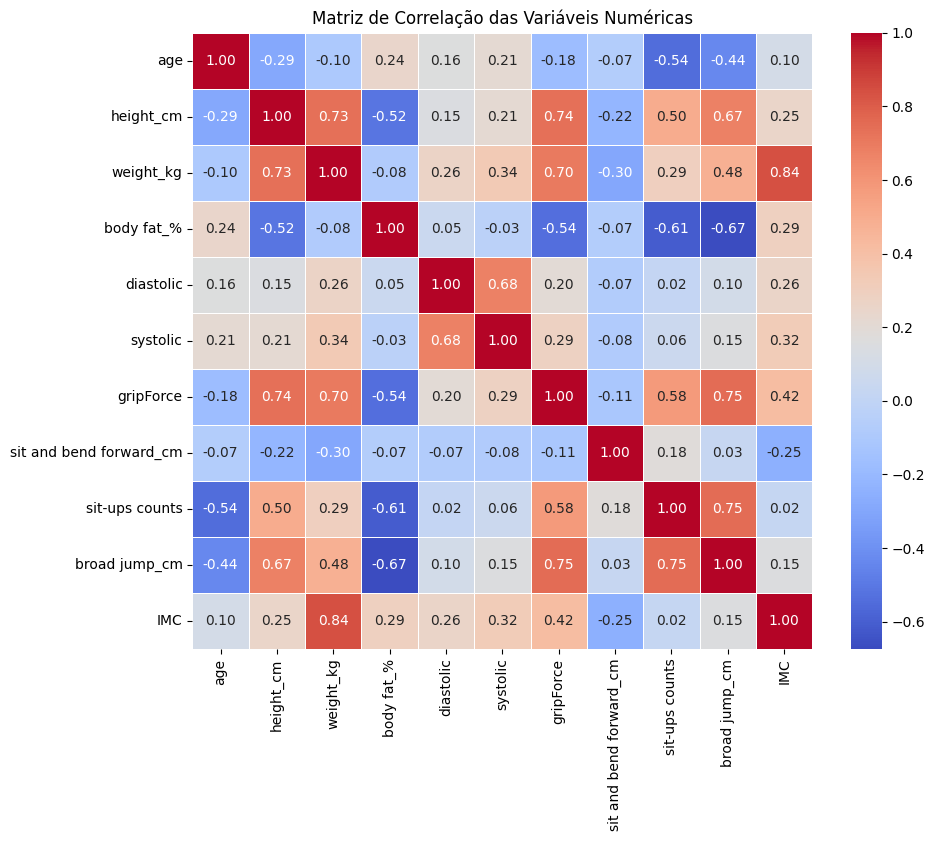

In [70]:
numeric_df = df.drop(columns=['gender', 'class']) # Cria um novo DataFrame apenas com as colunas numéricas (excluindo as categóricas)


corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show() 

#### **Interpretação da Matriz de Correlação das Variáveis Numéricas**

A matriz de correlação fornece uma visão estatística das relações lineares entre todos os pares de *features* numéricas do *dataset*. Valores próximos de +1.00 indicam correlação positiva forte, e valores próximos de -1.00 indicam correlação negativa forte.

**1. Correlações Positivas Fortes**

As correlações positivas mais fortes são observadas entre as métricas de aptidão física, o que é esperado:

- ***sit-ups counts vs. broad jump_cm* (0.75):** Indivíduos com maior resistência abdominal tendem a ter maior força explosiva nas pernas.

- ***sit-ups counts vs. gripForce* (0.58):** A força da pega está moderadamente ligada ao desempenho em abdominais.

- ***height_cm vs. weight_kg* (0.73) e *gripForce* (0.74):** Pessoas mais altas tendem a pesar mais e demonstram maior força de preensão.


**2. Correlações Negativas Fortes**

- ***body fat_% vs. sit-ups counts* (-0.61) e *broad jump_cm* (-0.67):** O aumento do percentual de gordura corporal está fortemente associado à diminuição do desempenho nos testes de aptidão (abdominais e salto), indicando que a composição corporal é um preditor chave do desempenho.

- ***age vs. sit-ups counts* (-0.54):** O aumento da idade está moderadamente associado à diminuição da contagem de abdominais.

- ***age vs. broad jump_cm* (-0.44):** A força explosiva também diminui com a idade.


**3. Correlação Baixa ou Nula**
- As métricas de pressão (*diastolic e systolic*) mostram correlações muito baixas com as métricas de aptidão física (salto, abdominais, força de preensão). Isto indica que o desempenho físico está largamente independente da pressão arterial dentro dos valores registados.

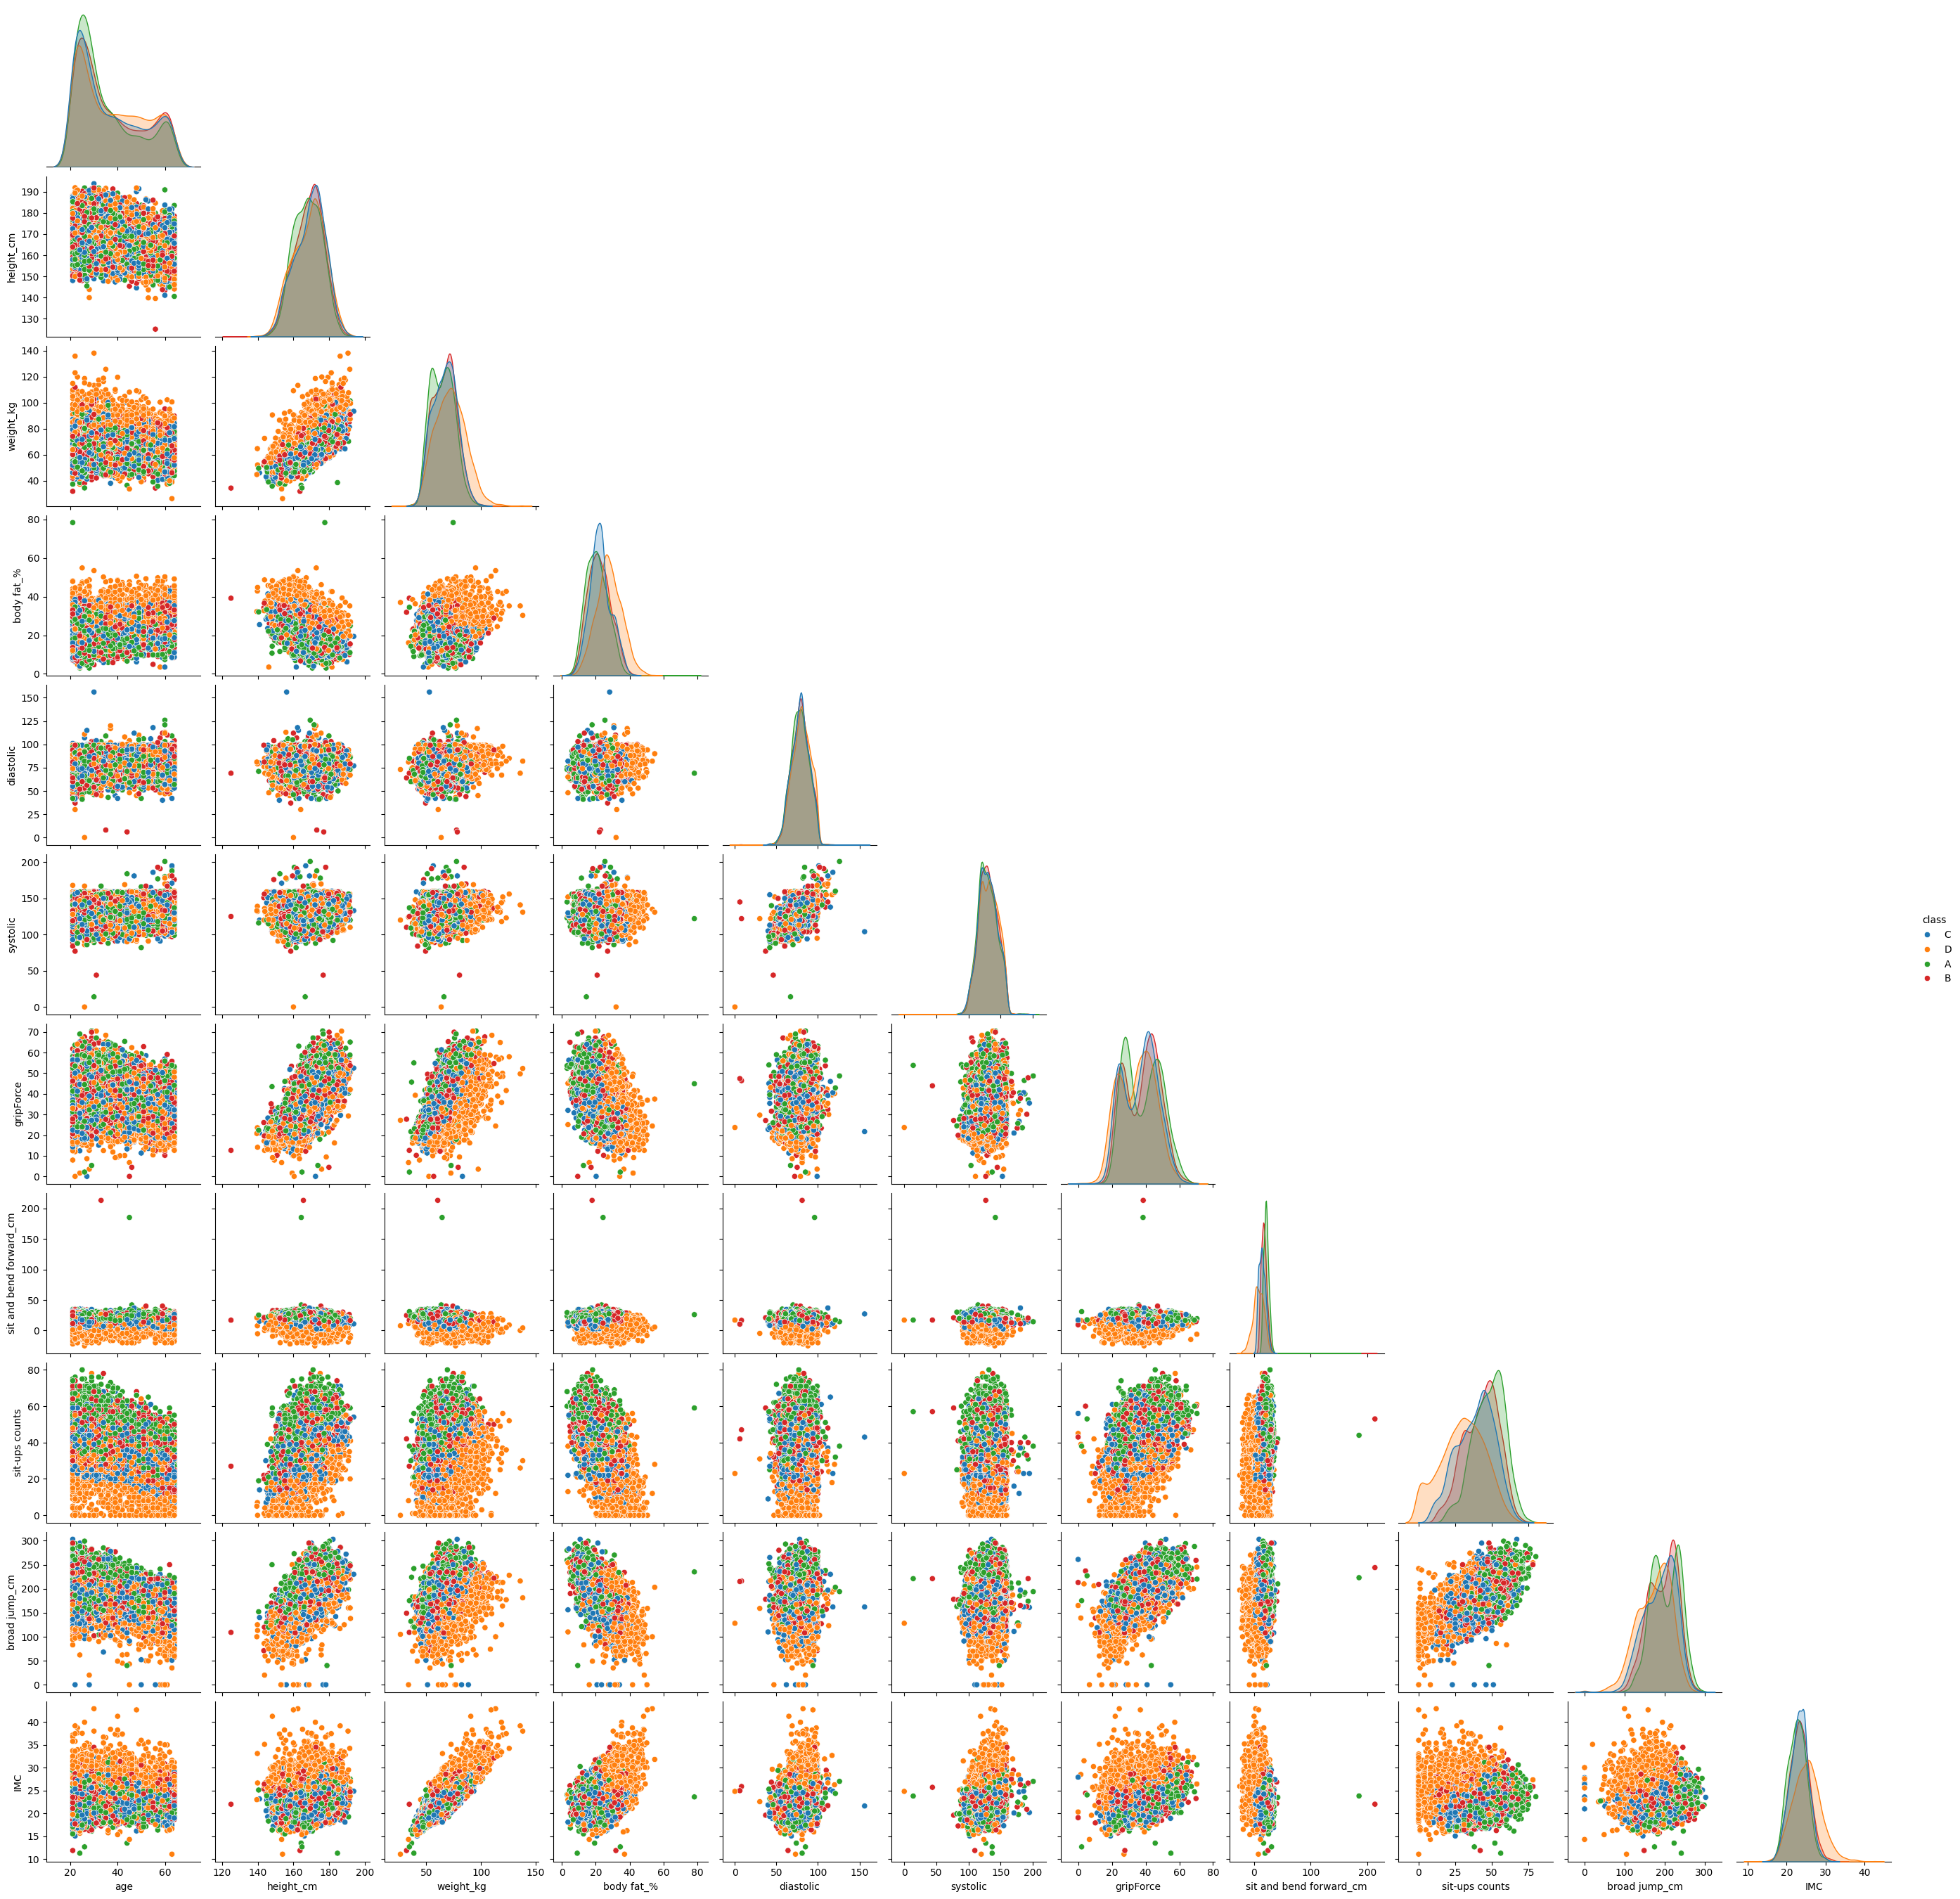

In [71]:
sns.pairplot(df, vars=numeric_df.columns, hue='class', hue_order=class_counts.index, corner=True)
plt.show()

## **8. Preparação Final e Exportação do Dataset**

As etapas finais do EDA incluem a codificação da variável categórica (*gender*) para a tornar utilizável pelos algoritmos e a exportação do ficheiro final.



#### **8.1. Codificação da Variável Categórica**

A coluna *gender* é codificada usando *One-Hot Encoding*, criando a coluna *is_male* (1 para Masculino, 0 para Feminino).

In [72]:
# Codificação da variável 'gender'
df_encoded = pd.get_dummies(df, columns=['gender'], drop_first=True) 

X = df_encoded.drop('class', axis=1) 
y = df_encoded['class'] 

print("\nPré-visualização de X (Features):")
print(X.head())


Pré-visualização de X (Features):
    age  height_cm  weight_kg  body fat_%  diastolic  systolic  gripForce  \
0  27.0      172.3      75.24        21.3       80.0     130.0       54.9   
1  25.0      165.0      55.80        15.7       77.0     126.0       36.4   
2  31.0      179.6      78.00        20.1       92.0     152.0       44.8   
3  32.0      174.5      71.10        18.4       76.0     147.0       41.4   
4  28.0      173.8      67.70        17.1       70.0     127.0       43.5   

   sit and bend forward_cm  sit-ups counts  broad jump_cm    IMC  gender_M  
0                     18.4            60.0          217.0  25.34      True  
1                     16.3            53.0          229.0  20.50      True  
2                     12.0            49.0          181.0  24.18      True  
3                     15.2            53.0          219.0  23.35      True  
4                     27.1            45.0          217.0  22.41      True  


#### **8.2. Exportação do Ficheiro Final**

Guardamos o DataFrame codificado e completo (df_encoded) para ser carregado diretamente na fase de modelação e teste.

In [73]:
# Renomeação da coluna codificada para clareza
if 'gender_M' in df_encoded.columns:
    df_encoded.rename(columns={'gender_M': 'is_male'}, inplace=True)
elif 'gender_F' in df_encoded.columns:
    df_encoded.rename(columns={'gender_F': 'is_female'}, inplace=True)



class_mapping = {
    'A': 0,  # Melhor Desempenho
    'B': 1,
    'C': 2,
    'D': 3   # Pior Desempenho
}

df_encoded['class_encoded'] = df_encoded['class'].map(class_mapping)
df_encoded['class_encoded'] = df_encoded['class_encoded'].astype(int)

df_encoded.drop('class', axis=1, inplace=True)
df_encoded.rename(columns={'class_encoded': 'class'}, inplace=True)

print("\nMapeamento da Codificação da Classe:")
print(class_mapping)

print("\nPré-visualização da classe codificada (usando Pandas.replace):")
print(df_encoded[['class']].head())


# Exportação do DataFrame
output_path = "data/prepared_classification.csv"

# Exporta o DataFrame final e processado para um ficheiro CSV
df_encoded.to_csv(output_path, index=False)

print("\nFicheiro exportado com sucesso em data/prepared_classification.csv")
print("\nficheiro exportado:")
print(df_encoded.head())


Mapeamento da Codificação da Classe:
{'A': 0, 'B': 1, 'C': 2, 'D': 3}

Pré-visualização da classe codificada (usando Pandas.replace):
   class
0      2
1      0
2      2
3      1
4      1

Ficheiro exportado com sucesso em data/prepared_classification.csv

ficheiro exportado:
    age  height_cm  weight_kg  body fat_%  diastolic  systolic  gripForce  \
0  27.0      172.3      75.24        21.3       80.0     130.0       54.9   
1  25.0      165.0      55.80        15.7       77.0     126.0       36.4   
2  31.0      179.6      78.00        20.1       92.0     152.0       44.8   
3  32.0      174.5      71.10        18.4       76.0     147.0       41.4   
4  28.0      173.8      67.70        17.1       70.0     127.0       43.5   

   sit and bend forward_cm  sit-ups counts  broad jump_cm    IMC  is_male  \
0                     18.4            60.0          217.0  25.34     True   
1                     16.3            53.0          229.0  20.50     True   
2                     12.0  

#### **Interpretação dos Resultados (Exportação)**

O *dataset prepared_classification.csv* está agora guardado. Contém todas as *features* e a variável-alvo, sendo o ponto de partida ideal para a aplicação de algoritmos de Classificação.
